In [1]:
import itertools

from matplotlib import pyplot as plt

from cr_knee_fit import experiments
from cr_knee_fit.elements import Element
from cr_knee_fit.fit_data import CRSpectrumData, Data, DataConfig, FluxRatioData, SpectrumDataConfig
from cr_knee_fit.plotting import (
    CARTO_VIVID,
    PosteriorPlotConfig,
    plot_model_predictions,
)
from cr_knee_fit.utils import R_GV_LABEL, legend_artist_line, legend_with_added_items

# Data showcase


In [2]:
ignore = {experiments.lhaaso_epos, experiments.lhaaso_qgsjet}

ALL = experiments.DIRECT + experiments.INDIRECT
conf = DataConfig(
    spectra=[
        SpectrumDataConfig(exp, element)
        for exp, element in itertools.product(ALL, Element.regular())
        if exp not in ignore
    ]
    + [
        SpectrumDataConfig.allparticle(exp)
        for exp in ALL
        if exp is not experiments.dampe
        if exp not in ignore
    ],
    lnA=[experiments.lhaaso_sibyll, experiments.tale],
)

d = Data.load(conf, verbose=True)

✅ AMS-02 H
✅ AMS-02 He
✅ AMS-02 Li
✅ AMS-02 Be
✅ AMS-02 B
✅ AMS-02 C
✅ AMS-02 N
✅ AMS-02 O
✅ AMS-02 F
✅ AMS-02 Ne
❌ AMS-02 Na: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Na_energy.txt not found.
✅ AMS-02 Mg
✅ AMS-02 Al
✅ AMS-02 Si
❌ AMS-02 P: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_P_energy.txt not found.
✅ AMS-02 S
❌ AMS-02 Cl: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Cl_energy.txt not found.
❌ AMS-02 Ar: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Ar_energy.txt not found.
❌ AMS-02 K: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_K_energy.txt not found.
❌ AMS-02 Ca: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Ca_energy.txt not found.
❌ AMS-02 Sc: /Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/data/output/AMS-02_Sc_energy.txt not found.
❌ AMS-02 Ti: /Users/njvh/Documents/Sci

In [3]:
import numpy as np

from cr_knee_fit.fit_data import GenericExperimentData


def load_gamma_spectrum(fname: str, custom_label: str):
    E_TeV, F, Fstat, Fsyst = np.loadtxt(fname, unpack=True)
    Fconv = 1e-3 * 1e4  # TeV^-1 cm^-2 -> GeV^-1 m^-2

    return CRSpectrumData(
        d=GenericExperimentData(
            x=E_TeV * 1e3,
            y=F * Fconv,
            err_stat=np.vstack((Fstat, Fstat)).T * Fconv,
            err_syst=np.vstack((Fsyst, Fsyst)).T * Fconv,
            experiment=experiments.lhaaso_sibyll,
            custom_label=custom_label,
        ),
        spec="gamma",
        quantity="E",
    )

In [4]:
gamma_outer = load_gamma_spectrum("../data/lake/LHAASO_outerGalaxy.txt", " (outer)")
gamma_inner = load_gamma_spectrum("../data/lake/LHAASO_innerGalaxy.txt", " (inner)")

d.spectra.extend((gamma_inner, gamma_outer))

Spectra:
AMS-02
    AMS-02 H: 72 points from 1.1e+00 to 1.4e+03 GeV; total relative error from 0.88% to 4.92%
    AMS-02 He: 68 points from 4.1e+00 to 4.6e+03 GeV; total relative error from 1.28% to 7.97%
    AMS-02 Li: 67 points from 6.1e+00 to 6.1e+03 GeV; total relative error from 2.59% to 20.81%
    AMS-02 Be: 67 points from 8.1e+00 to 8.1e+03 GeV; total relative error from 2.75% to 39.32%
    AMS-02 B: 66 points from 1.1e+01 to 1.0e+04 GeV; total relative error from 2.39% to 20.39%
    AMS-02 C: 68 points from 1.2e+01 to 1.4e+04 GeV; total relative error from 2.27% to 11.30%
    AMS-02 N: 66 points from 1.6e+01 to 1.4e+04 GeV; total relative error from 3.13% to 14.02%
    AMS-02 F: 48 points from 2.0e+01 to 1.7e+04 GeV; total relative error from 3.38% to 75.55%
    AMS-02 Ne: 48 points from 2.3e+01 to 1.9e+04 GeV; total relative error from 3.42% to 12.77%
    AMS-02 O: 67 points from 1.8e+01 to 1.9e+04 GeV; total relative error from 2.67% to 11.72%
    AMS-02 Mg: 66 points from 2.

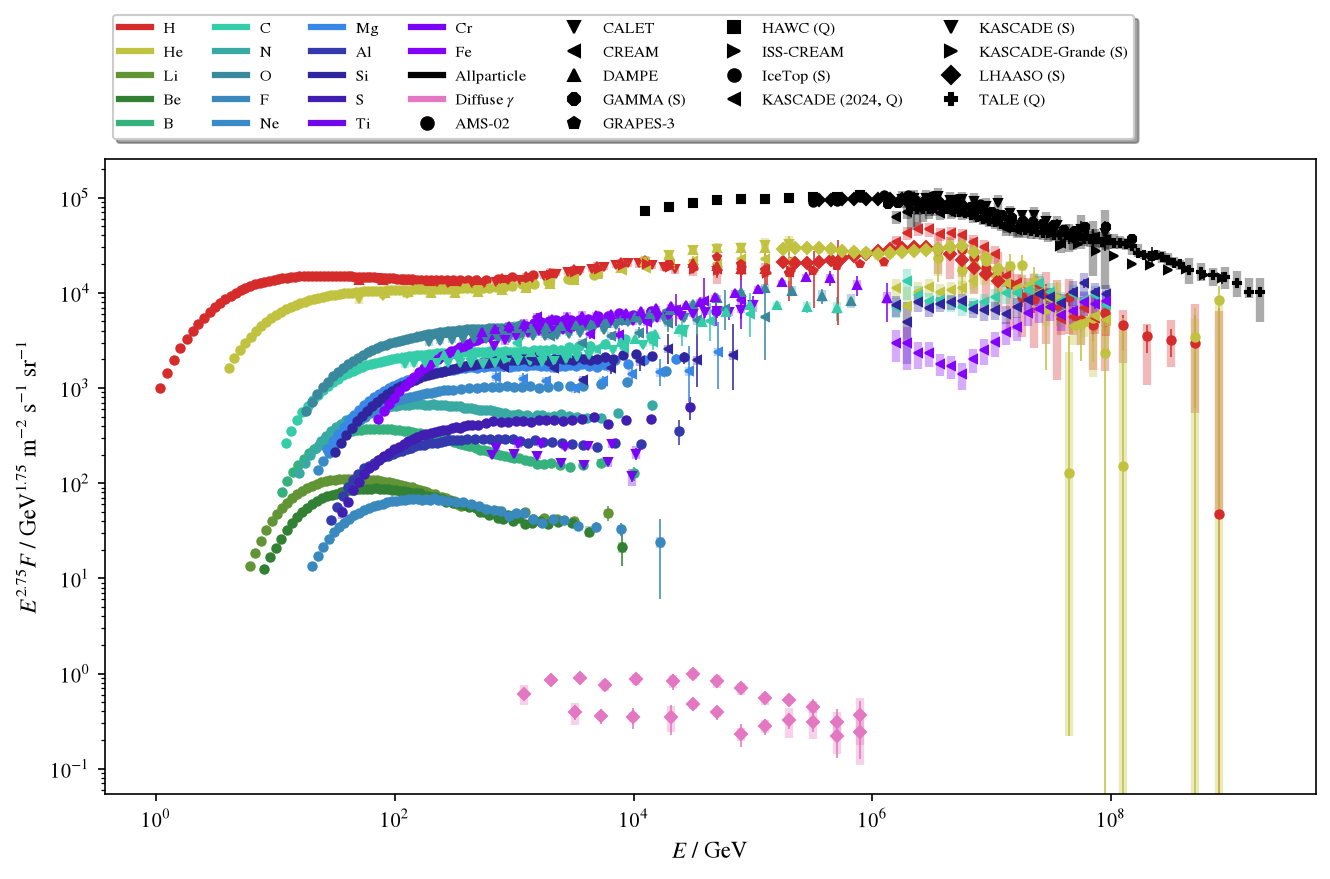

In [5]:
from cr_knee_fit.plotting import ALL_PARTICLE_COLOR

fig, ax = plt.subplots(figsize=(9, 6))
d.plot_spectra(describe=True, scale=2.75, is_fitted=True, ax=ax)
# ax.legend()
legend_with_added_items(
    ax,
    [(legend_artist_line(el.color, linewidth=3), el.name) for el in d.elements()]
    + [
        (legend_artist_line(ALL_PARTICLE_COLOR, linewidth=3), "Allparticle"),
        (legend_artist_line("tab:pink", linewidth=3), "Diffuse $\\gamma$"),
    ]
    + [(exp.legend_artist(True), exp.name) for exp in sorted(d.experiments(spectra_only=True))],
    fontsize="x-small",
    bbox_to_anchor=(0.00, 1.02, 1.0, 0.0),
    loc="lower left",
    fancybox=True,
    shadow=True,
    ncol=7,
)
fig.tight_layout()

lnA data:
    LHAASO (S) <lnA>: 20 points from 3.5e+05 to 2.8e+07 GeV; total relative error from 5.21% to 9.42%
    TALE (Q) <lnA>: 17 points from 3.5e+07 to 2.5e+09 GeV; total relative error from 15.08% to 208.50%


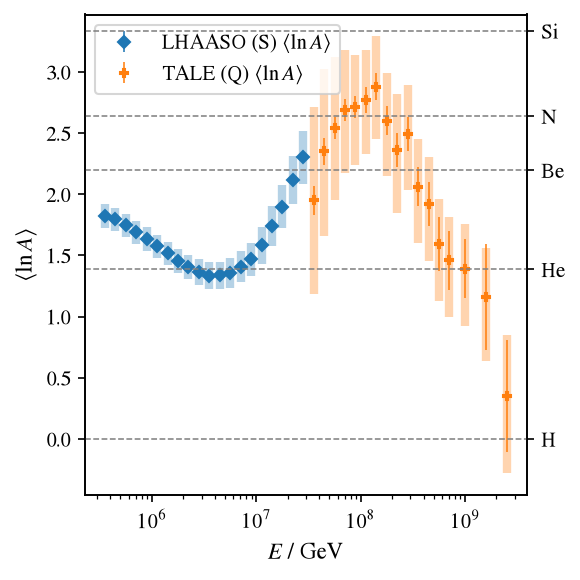

In [6]:
from cr_knee_fit.utils import add_elements_lnA_secondary_axis

fig, ax = plt.subplots(figsize=(4, 4))
d.plot_lnA(describe=True, is_fitted=True, ax=ax)
add_elements_lnA_secondary_axis(ax)
leg = ax.legend()
leg.set_zorder(100)
fig.tight_layout()

# H/He dip


In [7]:
lhaaso = experiments.lhaaso_sibyll

p = CRSpectrumData.load(lhaaso, Element.H)
He = CRSpectrumData.load(lhaaso, Element.He)

# fig, ax = plt.subplots()
# p.to_quantity("R").plot(scale=2.8, ax=ax)
# He.to_quantity("R").plot(scale=2.8, ax=ax)
# ax.set_xscale("log")
# ax.set_yscale("log")

lhaaso_p_He = FluxRatioData.from_fluxes(p, He, quantity="R", error_propagation="intervals")
# ax = lhaaso_p_He.plot()
# ax.set_xscale("log")
# ax.set_yscale("log")

In [8]:
dampe_p_He = FluxRatioData.from_fluxes(
    CRSpectrumData.load(experiments.dampe, Element.H),
    CRSpectrumData.load(experiments.dampe, Element.He),
    quantity="R",
    error_propagation="intervals",
)
# ax = dampe_p_He.plot()
# ax.set_xscale("log")
# ax.set_yscale("log")

In [9]:
from cr_knee_fit.analysis import AnalysisResults

onepop_res = AnalysisResults.load("../out/phase-6/crams_high_E_feature_break", subsample_size=300)
fiducial_res = AnalysisResults.load("../out/phase-6/twopop_kneebump", subsample_size=300)
threepop_res = AnalysisResults.load("../out/phase-6/threepop_kneebump", subsample_size=300)

In [10]:
from matplotlib.axes import Axes

p_over_He = Element.H / Element.He
ams = FluxRatioData.load(experiments.ams02, p_over_He)
calet = FluxRatioData.load(experiments.calet, p_over_He)

p_He_data = Data(config=DataConfig(), flux_ratios=[ams, calet])
p_He_data.flux_ratios.append(dampe_p_He)
p_He_data.flux_ratios.append(lhaaso_p_He)


def plot_p_He_data() -> Axes:
    _, ax = plt.subplots(figsize=(5, 4))
    for i, fr in enumerate(p_He_data.flux_ratios):
        fr.plot_in_R(
            ax=ax, is_fitted=True, color=CARTO_VIVID(i + 4), add_legend_label=fr.d.plot_label()
        )
    ax.set_xscale("log")
    ax.set_xlabel(R_GV_LABEL)
    ax.set_ylabel("H / He")
    return ax

/Users/njvh/Documents/Science/GSSI/HEAPTH/galactic-cr-fit/cr_knee_fit/crams_model.py:543: RuntimeWarning: divide by zero encountered in log10
  return np.log10(self.crams.compute(self.propagation, self.injection))


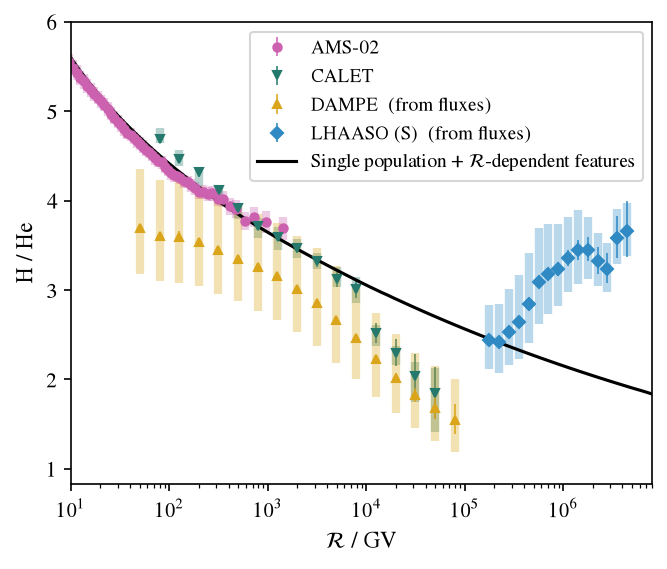

In [11]:
ax = plot_p_He_data()

Rmin = 10
Rmax = 8e6
plot_model_predictions(
    ax=ax,
    scale=0,
    E_bounds=(Rmin, Rmax),
    model_sample=onepop_res.model_sample,
    observable=lambda m, R: m.compute_flux_ratio(R, Element.H / Element.He, "R"),
    color="k",
    plot_config=PosteriorPlotConfig(band_cl=None),
    best=onepop_res.mle,
)

legend_with_added_items(
    ax,
    items=[
        (legend_artist_line("black"), "Single population + $\\mathcal {R}$-dependent features"),
    ],
    fontsize="small",
)

ax.set_xlim(Rmin, Rmax)
ax.set_ylim(top=6)
ax.set_yscale("linear")

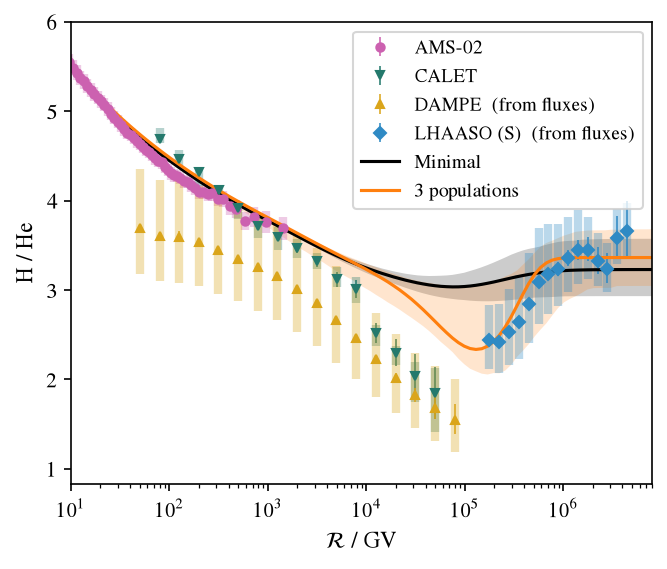

In [12]:
ax = plot_p_He_data()

Rmin = 10
Rmax = 8e6
for res, color in (
    (fiducial_res, "black"),
    (threepop_res, "tab:orange"),
):
    plot_model_predictions(
        ax=ax,
        scale=0,
        E_bounds=(Rmin, Rmax),
        model_sample=res.model_sample,
        observable=lambda m, R: m.compute_flux_ratio(R, Element.H / Element.He, "R"),
        color=color,
        plot_config=PosteriorPlotConfig(),
        best=res.mle,
    )

legend_with_added_items(
    ax,
    items=[
        (legend_artist_line("black"), "Minimal"),
        (legend_artist_line("tab:orange"), "3 populations"),
    ],
    fontsize="small",
)

ax.set_xlim(Rmin, Rmax)
ax.set_ylim(top=6)
ax.set_yscale("linear")

# Erfc cutoff demo


In [13]:
alpha = 2
R0 = 1e-1
mean_R_cut = 1
sigma_lgR_cut = 0.5


def single_source_heaviside(R: np.ndarray, Rcut: float) -> np.ndarray:
    return (R / R0) ** (-alpha) * (R < Rcut)


def single_source_exp(R: np.ndarray, Rcut: float) -> np.ndarray:
    return (R / R0) ** (-alpha) * np.exp(-R / Rcut)


def single_source_exp2(R: np.ndarray, Rcut: float) -> np.ndarray:
    return (R / R0) ** (-alpha) * np.exp(-((R / Rcut) ** 2))

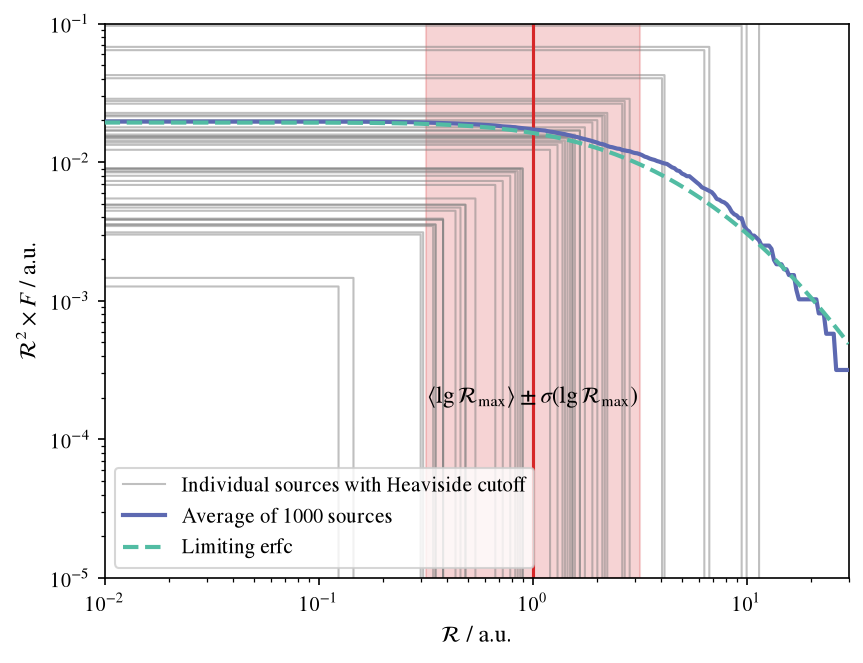

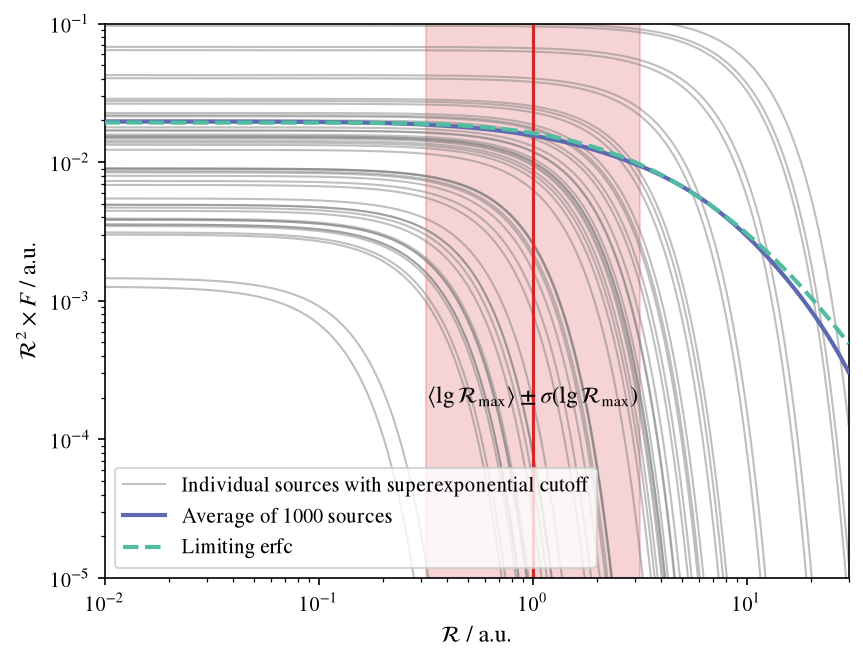

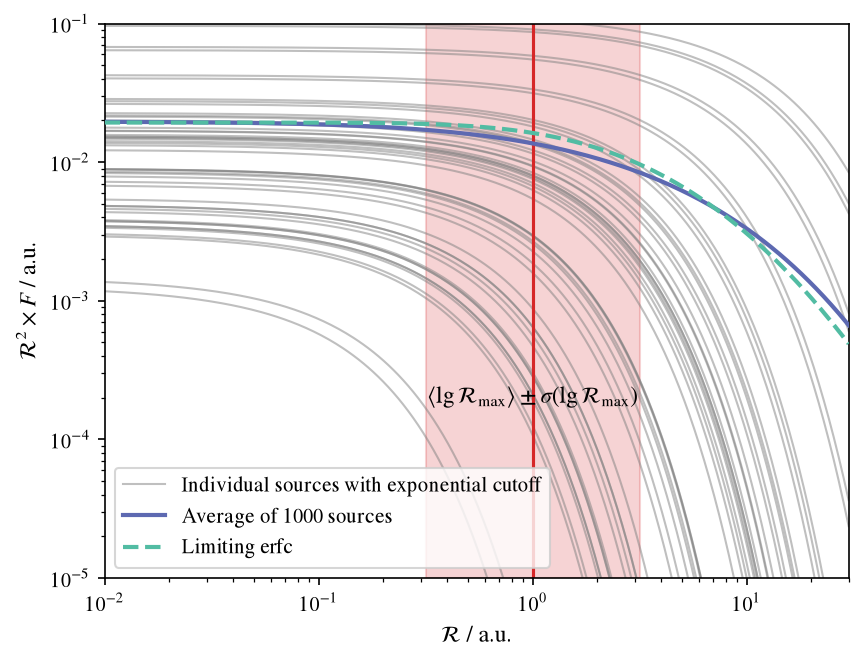

In [14]:
from scipy import special, stats

Rmax_sample = 10 ** stats.norm.rvs(np.log10(mean_R_cut), sigma_lgR_cut, size=1_000)

for single_source, cutoff_label, added_sigma in (
    (single_source_heaviside, "Heaviside", None),
    (single_source_exp2, "superexponential", None),
    (single_source_exp, "exponential", None),
):
    R_grid = np.geomspace(1e-2, 3e1, 300)
    beta = 1

    sources = []
    for Rmax in Rmax_sample:
        src = Rmax**beta * single_source(R_grid, Rmax)
        sources.append(src)

    fig, ax = plt.subplots()
    scale = 2

    for i, spec in enumerate(sources[:50]):
        ax.plot(
            R_grid,
            R_grid**scale * spec,
            lw=1,
            color="gray",
            alpha=0.5,
            label=f"Individual sources with {cutoff_label} cutoff" if i == 0 else None,
        )

    ax.plot(
        R_grid,
        R_grid**scale * np.mean(sources, axis=0),
        lw=2,
        color=CARTO_VIVID(1),
        zorder=100,
        label=f"Average of {Rmax_sample.size} sources",
    )

    lgR = np.log10(R_grid)
    lg_cut = np.log10(mean_R_cut)
    sigma_eff = sigma_lgR_cut
    if added_sigma is not None:
        sigma_eff += added_sigma
    theory_cutoff = 0.5 * special.erfc(
        (lgR - lg_cut - 2 * beta * sigma_eff**2) / (np.sqrt(2) * sigma_eff)
    )
    ax.plot(
        R_grid,
        # HACK: ad hoc re-scaling
        R_grid**scale * 1.9313280747903014 * (R_grid / R0) ** (-alpha) * theory_cutoff,
        lw=2,
        ls="--",
        color=CARTO_VIVID(2),
        zorder=100,
        label="Limiting $\\text{erfc}$"
        if added_sigma is None
        else f"Limiting $\\text{{erfc}}$ with added $\\sigma(\\lg \\mathcal{{R}}) = {added_sigma:.2g}$",
    )

    mean_lgR_cut = np.log10(mean_R_cut)
    ax.axvline(10**mean_lgR_cut, color="tab:red")
    ax.axvspan(
        10 ** (mean_lgR_cut - sigma_eff),
        10 ** (mean_lgR_cut + sigma_eff),
        color="tab:red",
        alpha=0.2,
    )
    ax.text(
        x=1.0,
        y=2e-4,
        s="$ \\langle \\lg \\mathcal{R}_\\text{max} \\rangle \\pm \\sigma(\\lg \\mathcal{R}_\\text{max}) $",
        ha="center",
        va="center",
    )

    ax.set_xlabel("$ \\mathcal{R} $ / a.u.")
    ax.set_ylabel("$ \\mathcal{R}^2 \\times F $ / a.u.")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.legend()
    ax.set_xlim(R_grid[0], R_grid[-1])
    ax.set_ylim(1e-5, 1e-1)

(1e-05, 0.1)

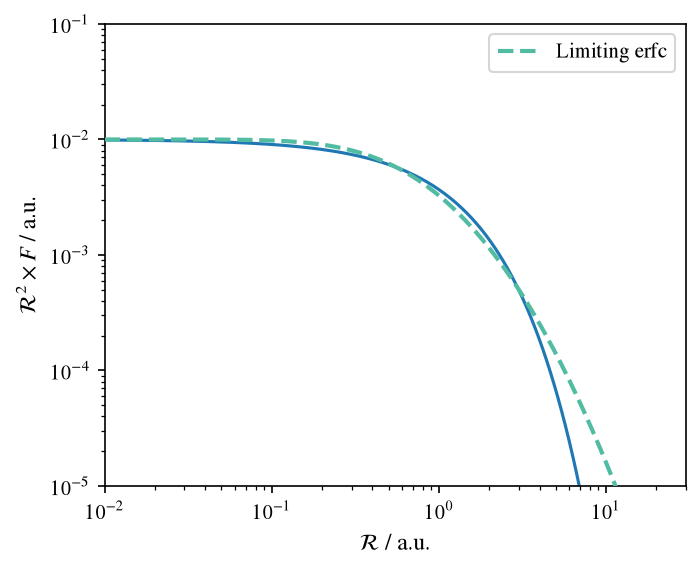

In [15]:
from scipy import special, stats

R_grid = np.geomspace(1e-2, 3e1, 300)
fig, ax = plt.subplots(figsize=(5, 4))
scale = 2

ax.plot(R_grid, R_grid**2 * single_source_exp(R_grid, mean_R_cut))

lgR = np.log10(R_grid)
lg_cut = np.log10(mean_R_cut) - 0.5
sigma_eff = 0.4
theory_cutoff = 0.5 * special.erfc(
    (lgR - lg_cut - 2 * beta * sigma_eff**2) / (np.sqrt(2) * sigma_eff)
)
ax.plot(
    R_grid,
    # HACK: ad hoc re-scaling
    R_grid**scale * (R_grid / R0) ** (-alpha) * theory_cutoff,
    lw=2,
    ls="--",
    color=CARTO_VIVID(2),
    zorder=100,
    label="Limiting $\\text{erfc}$"
    if added_sigma is None
    else f"Limiting $\\text{{erfc}}$ with added $\\sigma(\\lg \\mathcal{{R}}) = {added_sigma:.2g}$",
)

ax.set_xlabel("$ \\mathcal{R} $ / a.u.")
ax.set_ylabel("$ \\mathcal{R}^2 \\times F $ / a.u.")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.set_xlim(R_grid[0], R_grid[-1])
ax.set_ylim(1e-5, 1e-1)

# Population comparison


In [16]:
labels = fiducial_res.mle.labels(False)
sample = fiducial_res.posterior_sample
assert sample is not None
print(*labels, sep="\n")

LE lg R_b
LE Delta delta
LE D_0
LE q_H
LE q_He
LE q_C
LE q_N
LE q_O
LE q_Ne
LE q_Mg
LE q_Si
LE q_S
LE q_Fe
LE gamma_H
LE gamma_He
LE gamma_nuc
LE <lg R_max>
LE sigma(lg R_max)
HE lgI_{H}
HE lgI_{He}
HE lgI_{C}
HE lgI_{O}
HE lgI_{Fe}
HE alpha_{H, He, C, O, Fe}
HE <lg R_max>
HE sigma(lg R_max)
HE lg R^cut
HE lg b
lg(f_CALET)
lg(f_DAMPE)
lg(f_LHAASO (S))


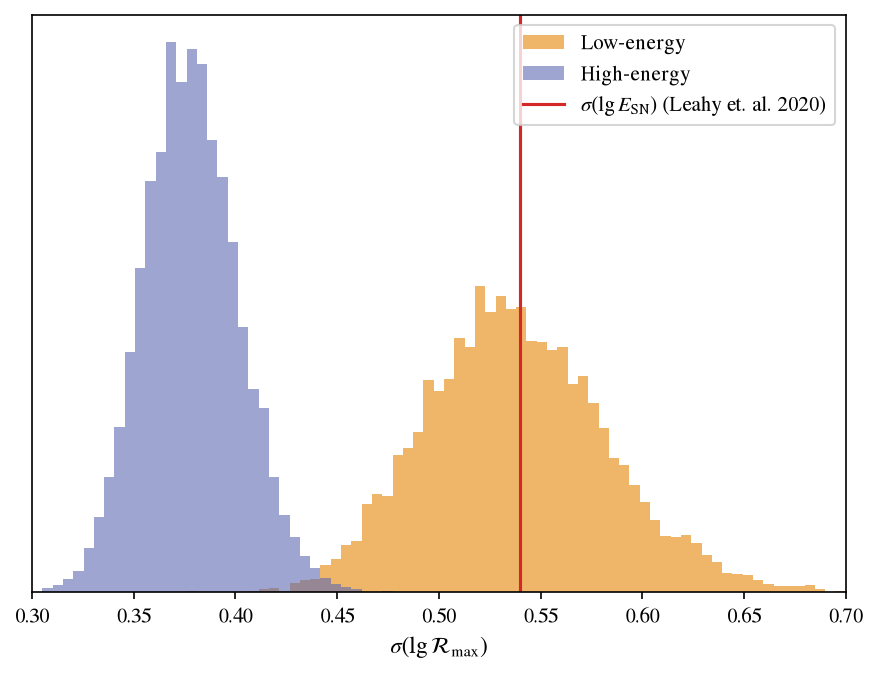

In [17]:
le_sigma_idx = labels.index("LE sigma(lg R_max)")
he_sigma_idx = labels.index("HE sigma(lg R_max)")

fig, ax = plt.subplots(figsize=(7, 5))

sigma_bins = np.linspace(0.3, 0.7, 80)
ax.hist(
    sample[:, le_sigma_idx],
    bins=sigma_bins,
    alpha=0.6,
    color=CARTO_VIVID(0),
    label="Low-energy",
)
ax.hist(
    sample[:, he_sigma_idx],
    bins=sigma_bins,
    alpha=0.6,
    color=CARTO_VIVID(1),
    label="High-energy",
)
ax.axvline(0.54, color="tab:red", label="$ \\sigma(\\lg E_\\text{SN}) $ (Leahy et. al. 2020)")

ax.set_yticks([])
ax.set_xlabel("$ \\sigma ( \\lg \\mathcal{R}_\\text{max} )$")

ax.set_xlim(0.3, 0.7)
ax.legend()

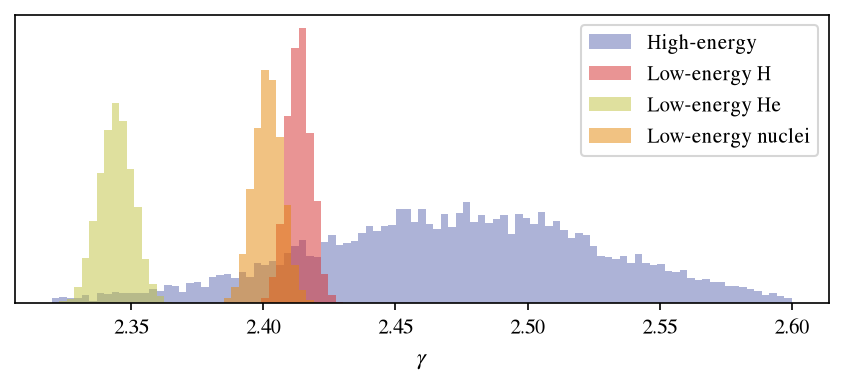

In [18]:
he_alpha = sample[:, labels.index("HE alpha_{H, He, C, O, Fe}")]
le_alpha_H = sample[:, labels.index("LE gamma_H")] - 2
le_alpha_He = sample[:, labels.index("LE gamma_He")] - 2
le_alpha_nuclei = sample[:, labels.index("LE gamma_nuc")] - 2

fig, ax = plt.subplots(figsize=(7, 2.5))

alpha_bins = np.linspace(2.32, 2.6, 100)
alpha = 0.5
ax.hist(
    np.concatenate([he_alpha] * 4),
    bins=alpha_bins,
    alpha=alpha,
    color=CARTO_VIVID(1),
    label="High-energy",
)
ax.hist(le_alpha_H, bins=alpha_bins, alpha=alpha, color=Element.H.color, label="Low-energy H")
ax.hist(le_alpha_He, bins=alpha_bins, alpha=alpha, color=Element.He.color, label="Low-energy He")
ax.hist(
    le_alpha_nuclei, bins=alpha_bins, alpha=alpha, color=CARTO_VIVID(0), label="Low-energy nuclei"
)

ax.set_yticks([])
ax.set_xlabel("$ \\gamma$")

ax.legend()

# 2 / 3 pop detailed comparison


In [20]:
fit_data = Data.load(fiducial_res.config.fit_data_config)

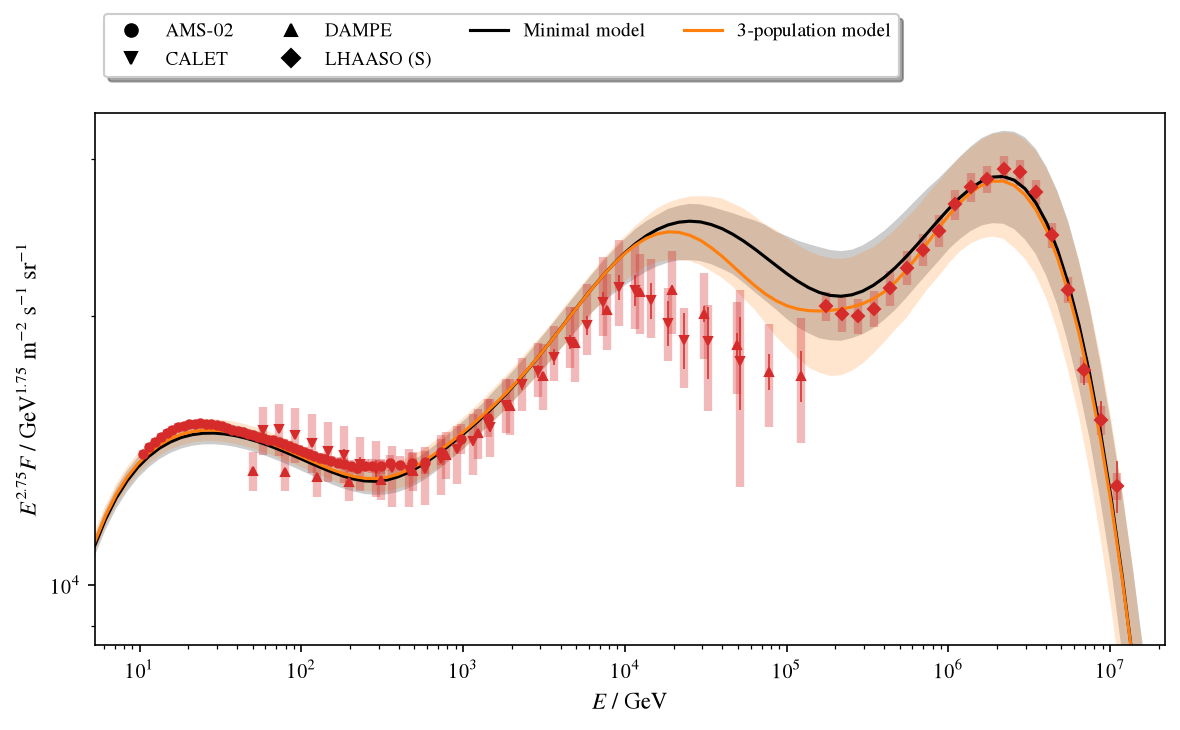

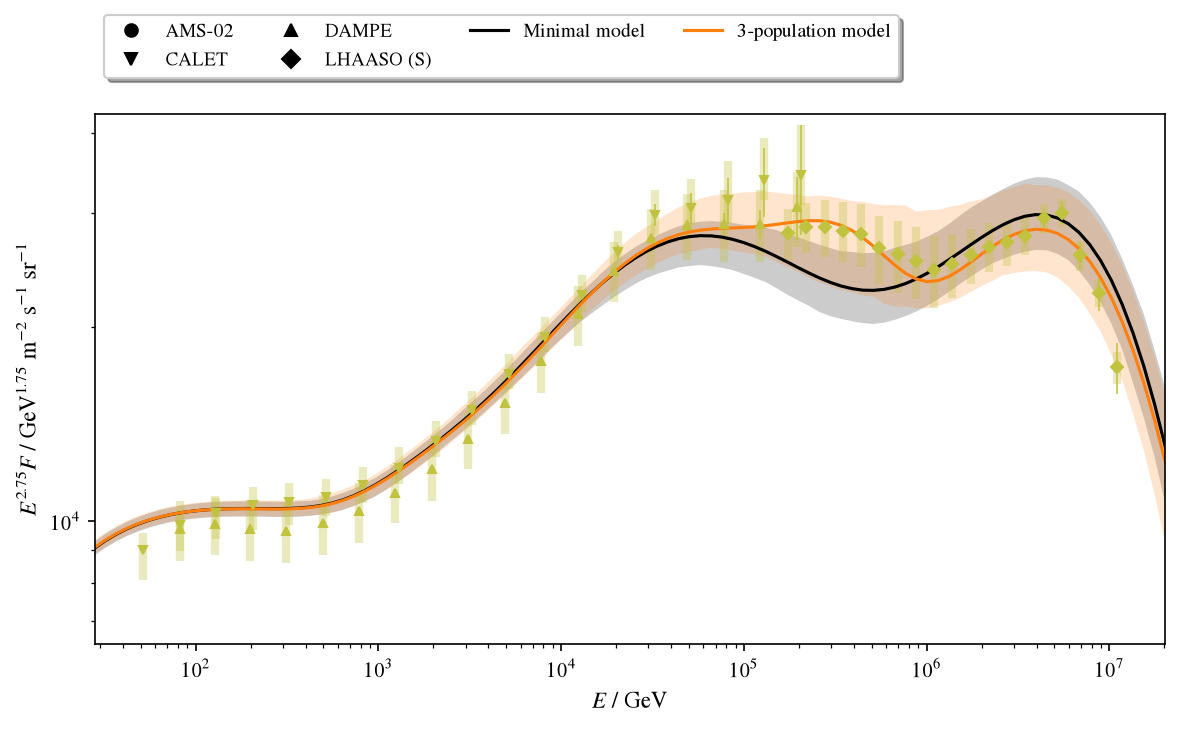

In [ ]:
from cr_knee_fit.plotting import plot_spectrum

for element in (Element.H, Element.He):
    fig, ax = plt.subplots(figsize=(8, 5))
    scale = 2.75
    plot_spectrum(
        spec=element,
        config=PosteriorPlotConfig(),
        center=fiducial_res.mle,
        model_sample=fiducial_res.model_sample,
        scale=scale,
        fit_data=fit_data,
        validation_data=Data(config=DataConfig()),
        legend_ncol=4,
        axes=ax,
    )

    # E_grid = np.geomspace(*ax.get_xlim(), 100)
    # E_factor = E_grid**scale
    # ax.plot(E_grid, E_factor * threepop_res.mle.compute_spectrum(E_grid, element, "E"), color="orange")

    plot_model_predictions(
        ax=ax,
        best=threepop_res.mle,
        model_sample=threepop_res.model_sample,
        observable=lambda model, E: model.compute_spectrum(E, element, "E"),  # noqa: B023
        E_bounds=ax.get_xlim(),
        plot_config=PosteriorPlotConfig(),
        color="tab:orange",
        scale=scale,
    )

    legend_with_added_items(
        ax,
        [
            (exp.legend_artist(is_fitted=True), exp.name)
            for exp in fit_data.experiments(spectra_only=True)
        ]
        + [
            (legend_artist_line("k"), "Minimal model"),
            (legend_artist_line("tab:orange"), "3-population model"),
        ],
        fontsize="small",
        bbox_to_anchor=(0.00, 1.05, 1.0, 0.0),
        loc="lower left",
        fancybox=True,
        shadow=True,
        ncol=4,
    )
    fig.tight_layout()